<a href="https://colab.research.google.com/github/arthurweslen/PowerQuery_DAX/blob/main/Visuals/Card_Minimalista_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Card Minimalista HTML


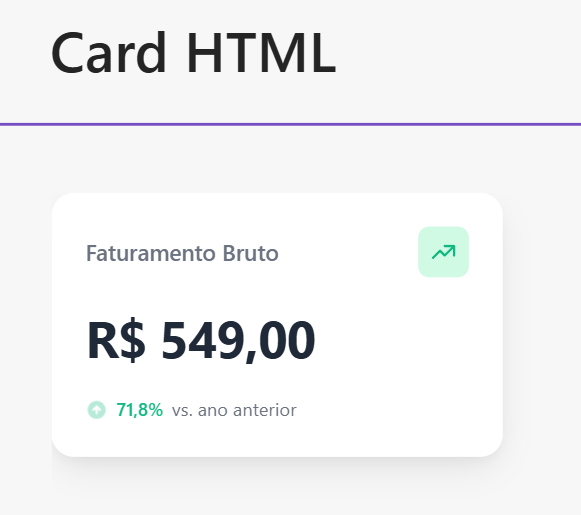

In [ ]:
HTML card-minimalista=
//======================================================
//==================== VALORES ========================
VAR FaturamentoAtual    = [faturamento_bruto]
VAR ValorYoY            = [faturamento_bruto YoY %]
//======================================================



-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                  🎨 PAINEL DE CONTROLE VISUAL                   ║
-- ║   Ajuste tudo aqui sem precisar mexer no HTML lá embaixo        ║
-- ╚══════════════════════════════════════════════════════════════════╝


-- ──────── 🏷️ TEXTOS FIXOS ────────
VAR varTituloCard       = "Faturamento Bruto"
VAR varTextoComparativo = "vs. ano anterior"

-- ──────── 🎨 CORES — STATUS POSITIVO ────────
VAR CorTextoPosi        = "#10B981"   -- verde
VAR CorFundoIconePosi   = "#D1FAE5"   -- verde claro (fundo do ícone)

-- ──────── 🎨 CORES — STATUS NEGATIVO ────────
VAR CorTextoNega        = "#EF4444"   -- vermelho
VAR CorFundoIconeNega   = "#FEE2E2"   -- vermelho claro (fundo do ícone)

-- ──────── 🎨 CORES — CARD ────────
VAR CorFundoCard        = "#FFFFFF"
VAR CorSombra           = "0 10px 25px -5px rgba(0,0,0,0.10), 0 4px 10px -6px rgba(0,0,0,0.10)"
VAR CorTitulo           = "#6B7280"   -- cinza médio
VAR CorValor            = "#1F2937"   -- cinza escuro
VAR CorTextoSecundario  = "#6B7280"   -- cinza médio


-- ──────── 📐 DIMENSÕES DO CARD ────────
VAR RaioBordaCard       = "16px"
VAR PaddingCard         = "24px"


-- ──────── 📏 TIPOGRAFIA ────────
VAR FonteGlobal         = "system-ui, -apple-system, sans-serif"
VAR TamanhoTitulo       = "16px"     -- "Faturamento"
VAR PesoTitulo          = "500"
VAR TamanhoValor        = "36px"     -- valor principal (R$ 2,3 K)
VAR PesoValor           = "700"
VAR TamanhoComparativo  = "13px"     -- "vs. ano anterior"
VAR TamanhoVariacao     = "13px"     -- percentual YoY
VAR PesoVariacao        = "600"


-- ──────── ✨ ANIMAÇÃO DO ÍCONE ────────
-- TRUE = ícone pisca  |  FALSE = ícone estático
VAR AnimarIcone         = TRUE()
-- Velocidade do piscar em segundos (ex: "1s" = rápido | "2.5s" = lento)
VAR VelocidadeAnim      = "1.5s"

-- ──────── 🔢 FORMATAÇÃO DE VALORES ────────
-- TRUE = K / M / B  |  FALSE = valor completo
VAR AbreviarValores     = TRUE()
VAR CasasDecimais       = "1"        -- casas após vírgula na abreviação


-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                   ⚙️ LÓGICA DE NEGÓCIO                          ║
-- ║   Normalmente não é necessário mexer abaixo desta linha         ║
-- ╚══════════════════════════════════════════════════════════════════╝

-- ── Métricas do modelo ────────────────────────────────────────────
-- ── Formatação do valor principal ─────────────────────────────────
VAR _fmt                = "#,##0." & REPT("0", VALUE(CasasDecimais))
VAR FatAbsoluto         = ABS(FaturamentoAtual)
VAR FatFormatado =
    IF(
        AbreviarValores,
        SWITCH(TRUE(),
            FatAbsoluto >= 1000000000, "R$ " & FORMAT(FaturamentoAtual / 1000000000, _fmt) & " B",
            FatAbsoluto >= 1000000,    "R$ " & FORMAT(FaturamentoAtual / 1000000,    _fmt) & " M",
            FatAbsoluto >= 1000,       "R$ " & FORMAT(FaturamentoAtual / 1000,       _fmt) & " K",
            "R$ " & FORMAT(FaturamentoAtual, "#,##0.00")
        ),
        "R$ " & FORMAT(FaturamentoAtual, "#,##0.00")
    )

-- ── Formatação do YoY ─────────────────────────────────────────────
VAR YoYFormatado        = FORMAT(ABS(ValorYoY), "0.0%")
VAR YoYEhPositivo       = ValorYoY >= 0

-- ── Cores dinâmicas por status ────────────────────────────────────
VAR CorStatus           = IF(YoYEhPositivo, CorTextoPosi,      CorTextoNega)
VAR CorFundoIcone       = IF(YoYEhPositivo, CorFundoIconePosi,  CorFundoIconeNega)

-- ── Ícone SVG de seta (para cima ou para baixo) ───────────────────
VAR PathSetaCima =
    "M13 7h8m0 0v8m0-8l-8 8-4-4-6 6"

VAR PathSetaBaixo =
    "M13 17h8m0 0V9m0 8l-8-8-4 4-6-6"

VAR PathSeta        = IF(YoYEhPositivo, PathSetaCima, PathSetaBaixo)
VAR IconeSeta =
    "<svg xmlns='http://www.w3.org/2000/svg' width='20' height='20' fill='none' " &
    "viewBox='0 0 24 24' stroke='" & CorStatus & "' stroke-width='2'>" &
    "<path stroke-linecap='round' stroke-linejoin='round' d='" & PathSeta & "'/>" &
    "</svg>"

-- ── Ícone de bolinha piscante (indicador de tendência) ────────────
VAR PathBolinhaCima =
    "M10 18a8 8 0 100-16 8 8 0 000 16zm3.707-8.707l-3-3a1 1 0 00-1.414 " &
    "0l-3 3a1 1 0 001.414 1.414L9 9.414V13a1 1 0 102 0V9.414l1.293 " &
    "1.293a1 1 0 001.414-1.414z"

VAR PathBolinhaBaixo =
    "M10 18a8 8 0 100-16 8 8 0 000 16zm-.707-4.293l3-3a1 1 0 00-1.414 " &
    "-1.414L10 10.586 8.707 9.293a1 1 0 00-1.414 1.414l2 2a1 1 0 001.414 0z"

VAR PathBolinha     = IF(YoYEhPositivo, PathBolinhaCima, PathBolinhaBaixo)
VAR ClasseAnim      = IF(AnimarIcone, "piscante", "")
VAR IconeBolinha =
    "<svg class='" & ClasseAnim & "' width='16' height='16' xmlns='http://www.w3.org/2000/svg' " &
    "viewBox='0 0 20 20' fill='" & CorStatus & "'>" &
    "<path fill-rule='evenodd' d='" & PathBolinha & "' clip-rule='evenodd'/>" &
    "</svg>"


RETURN
"<!DOCTYPE html>
<html lang='pt-BR'>
<head>
  <meta charset='UTF-8'>
  <meta name='viewport' content='width=device-width, initial-scale=1.0'>
  <style>
    html, body {
      margin: 0; padding: 0;
      width: 100%; height: 100%;
      font-family: " & FonteGlobal & ";
      background: transparent;
      display: flex;
      align-items: center;
      justify-content: center;
    }

    /* ── Card ── */
    .card {
      background: " & CorFundoCard & ";
      border-radius: " & RaioBordaCard & ";
      padding: " & PaddingCard & ";
      box-shadow: " & CorSombra & ";
      width: 100%;
      max-width: 320px;
      box-sizing: border-box;
    }

    /* ── Linha do topo: título + ícone ── */
    .topo {
      display: flex;
      align-items: center;
      justify-content: space-between;
      margin-bottom: 16px;
    }
    .titulo {
      font-size: " & TamanhoTitulo & ";
      font-weight: " & PesoTitulo & ";
      color: " & CorTitulo & ";
    }
    .icone-wrap {
      background: " & CorFundoIcone & ";
      padding: 8px;
      border-radius: 8px;
      display: flex;
      align-items: center;
      justify-content: center;
    }

    /* ── Valor principal ── */
    .valor {
      font-size: " & TamanhoValor & ";
      font-weight: " & PesoValor & ";
      color: " & CorValor & ";
      margin-bottom: 14px;
      letter-spacing: -0.5px;
    }

    /* ── Linha inferior: bolinha + % + comparativo ── */
    .rodape {
      display: flex;
      align-items: center;
      gap: 6px;
    }
    .variacao {
      font-size: " & TamanhoVariacao & ";
      font-weight: " & PesoVariacao & ";
      color: " & CorStatus & ";
    }
    .comparativo {
      font-size: " & TamanhoComparativo & ";
      color: " & CorTextoSecundario & ";
    }

    /* ── Animação de piscar ── */
    @keyframes piscar {
      0%, 100% { opacity: 1; }
      50%       { opacity: 0.25; }
    }
    .piscante {
      animation: piscar " & VelocidadeAnim & " infinite;
    }
  </style>
</head>
<body>
  <div class='card'>

    <!-- Topo: título + ícone de seta -->
    <div class='topo'>
      <span class='titulo'>" & varTituloCard & "</span>
      <div class='icone-wrap'>" & IconeSeta & "</div>
    </div>

    <!-- Valor principal -->
    <div class='valor'>" & FatFormatado & "</div>

    <!-- Rodapé: bolinha piscante + YoY + comparativo -->
    <div class='rodape'>
      " & IconeBolinha & "
      <span class='variacao'>" & YoYFormatado & "</span>
      <span class='comparativo'>" & varTextoComparativo & "</span>
    </div>

  </div>
</body>
</html>"

